<a href="https://colab.research.google.com/github/ojaspaul123/Projects/blob/main/Amazon-Sentiment-Analysis/Amazon_Sales_Review.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kagglehub ipython-sql

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 65.9 MB/s eta 0:00:00


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("karkavelrajaj/amazon-sales-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'amazon-sales-dataset' dataset.
Path to dataset files: /kaggle/input/amazon-sales-dataset


In [3]:
%%markdown
---
Dataset Download & Load

---
Dataset Download & Load


In [4]:
import pandas as pd
import os
from google.colab import files
uploaded = files.upload()
print(os.listdir(path))
df = pd.read_csv('amazon_file.csv')
print(df.columns)
print(df.head())

Saving amazon_file.csv to amazon_file.csv
['amazon.csv']
Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link'],
      dtype='object')
   product_id                                       product_name  \
0  B07JW9H4J1  Wayona Nylon Braided USB to Lightning Fast Cha...   
1  B098NS6PVG  Ambrane Unbreakable 60W / 3A Fast Charging 1.5...   
2  B096MSW6CT  Sounce Fast Phone Charging Cable & Data Sync U...   
3  B08HDJ86NZ  boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...   
4  B08CF3B7N1  Portronics Konnect L 1.2M Fast Charging 3A 8 P...   

                                            category discounted_price  \
0  Computers&Accessories|Accessories&Peripherals|...             ₹399   
1  Computers&Accessories|Accessories&Peripherals|...             ₹199   
2  Computers&Accessor

In [5]:
df.shape

(1465, 16)

In [6]:
print(df.columns.tolist())

['product_id', 'product_name', 'category', 'discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count', 'about_product', 'user_id', 'user_name', 'review_id', 'review_title', 'review_content', 'img_link', 'product_link']


In [35]:
%%markdown
---
Real NLP Sentiment Analysis (Fix for Issue #7)

---
Real NLP Sentiment Analysis (Fix for Issue #7)


In [34]:
from textblob import TextBlob

def get_text_sentiment(text):
    """
    Returns NLP-based sentiment using TextBlob polarity.
    polarity: -1.0 (very negative) to +1.0 (very positive)
    """
    combined = str(text)
    blob = TextBlob(combined)
    polarity = blob.sentiment.polarity
    subjectivity = blob.sentiment.subjectivity

    if polarity > 0.1:
        label = 'Positive'
    elif polarity < -0.1:
        label = 'Negative'
    else:
        label = 'Neutral'

    return polarity, subjectivity, label

df['combined_review'] = df['review_title'].astype(str) + ' ' + df['review_content'].astype(str)

# Apply NLP sentiment
print('Running NLP sentiment analysis on review text...')
results = df['combined_review'].apply(get_text_sentiment)
df['nlp_polarity'] = results.apply(lambda x: x[0])
df['nlp_subjectivity'] = results.apply(lambda x: x[1])
df['nlp_sentiment'] = results.apply(lambda x: x[2])


df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['rating_sentiment'] = df['rating'].apply(
    lambda r: 'Positive' if pd.notna(r) and r >= 4 else ('Neutral' if pd.notna(r) and r == 3 else 'Negative')
)

print('Done!')
df[['review_title', 'review_content', 'rating', 'nlp_polarity', 'nlp_sentiment', 'rating_sentiment']].head(10)

Running NLP sentiment analysis on review text...
Done!


,review_title,review_content,rating,nlp_polarity,nlp_sentiment,rating_sentiment
0,"Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,4.2,0.473958,Positive,Positive
1,"A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,4.0,0.294589,Positive,Positive
2,"Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",3.9,0.500000,Positive,Negative
3,"Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",4.2,0.331795,Positive,Positive
4,"As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",4.2,0.260013,Positive,Positive
5,"It's pretty good,Average quality,very good and...","It's a good product.,Like,Very good item stron...",3.9,0.454333,Positive,Negative
6,"Long durable.,good,Does not charge Lenovo m8 t...",Build quality is good and it is comes with 2 y...,4.1,0.495833,Positive,Positive
7,"Worth for money - suitable for Android auto,Go...",Worth for money - suitable for Android auto......,4.3,0.427564,Positive,Positive
8,Works on linux for me. Get the model with ante...,I use this to connect an old PC to internet. I...,4.2,0.270688,Positive,Positive
9,"A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,4.0,0.294589,Positive,Positive


In [7]:
%%markdown
---
Database Setup

---
Database Setup


In [8]:
import sqlite3

conn = sqlite3.connect("feedback.db")
df.to_sql("reviews", conn, if_exists="replace", index=False)

%load_ext sql
%sql sqlite:///feedback.db

In [9]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("feedback.db")

def sql(query):
    return pd.read_sql(query, conn)

# Now use it like this
sql("SELECT * FROM reviews LIMIT 5")

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [10]:
sql("SELECT category, AVG(rating) FROM reviews GROUP BY category")

,category,AVG(rating)
0,Car&Motorbike|CarAccessories|InteriorAccessori...,3.800000
1,Computers&Accessories|Accessories&Peripherals|...,4.150000
2,Computers&Accessories|Accessories&Peripherals|...,3.500000
3,Computers&Accessories|Accessories&Peripherals|...,3.600000
4,Computers&Accessories|Accessories&Peripherals|...,4.050000
...,...,...
206,OfficeProducts|OfficePaperProducts|Paper|Stati...,4.250000
207,OfficeProducts|OfficePaperProducts|Paper|Stati...,4.150000
208,OfficeProducts|OfficePaperProducts|Paper|Stati...,4.300000
209,OfficeProducts|OfficePaperProducts|Paper|Stati...,4.133333


In [11]:
%%markdown
---
Data Cleaning & Preprocessing

---
Data Cleaning & Preprocessing


In [12]:
print(df['category'].unique()[:10])
print("\n")

print(df['category'].value_counts().head(10))

['Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables'
 'Computers&Accessories|NetworkingDevices|NetworkAdapters|WirelessUSBAdapters'
 'Electronics|HomeTheater,TV&Video|Accessories|Cables|HDMICables'
 'Electronics|HomeTheater,TV&Video|Televisions|SmartTelevisions'
 'Electronics|HomeTheater,TV&Video|Accessories|RemoteControls'
 'Electronics|HomeTheater,TV&Video|Televisions|StandardTelevisions'
 'Electronics|HomeTheater,TV&Video|Accessories|TVMounts,Stands&Turntables|TVWall&CeilingMounts'
 'Electronics|HomeTheater,TV&Video|Accessories|Cables|RCACables'
 'Electronics|HomeAudio|Accessories|SpeakerAccessories|Mounts'
 'Electronics|HomeTheater,TV&Video|Accessories|Cables|OpticalCables']


category
Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables                        233
Electronics|WearableTechnology|SmartWatches                                                               76
Electronics|Mobiles&Accessories|Smartphones&BasicMo

In [13]:
df['main_category'] = df['category'].apply(lambda x: str(x).split('|')[0])
print(df['main_category'].unique())

['Computers&Accessories' 'Electronics' 'MusicalInstruments'
 'OfficeProducts' 'Home&Kitchen' 'HomeImprovement' 'Toys&Games'
 'Car&Motorbike' 'Health&PersonalCare']


In [14]:
###Clean special characters and extra spaces
df['main_category'] = df['main_category'].str.strip()
df['main_category'] = df['main_category'].str.replace('&', ' and ')
print(df['main_category'].unique())

['Computers and Accessories' 'Electronics' 'MusicalInstruments'
 'OfficeProducts' 'Home and Kitchen' 'HomeImprovement' 'Toys and Games'
 'Car and Motorbike' 'Health and PersonalCare']


In [15]:
### Check null values
print(df[['main_category', 'rating', 'review_content', 'product_name']].isnull().sum())

df['main_category'] = df['main_category'].fillna('Unknown')

main_category     0
rating            0
review_content    0
product_name      0
dtype: int64


In [16]:
###Remove Duplicates
print("Before:", df.shape)
df = df.drop_duplicates()
print("After:", df.shape)

Before: (1465, 17)
After: (1465, 17)


In [17]:
###Reload cleaned data into SQL
df.to_sql("reviews", conn, if_exists="replace", index=False)
print("Clean data loaded into database..")
print("Total rows:", len(df))
print("Columns:", df.columns.tolist())

Clean data loaded into database..
Total rows: 1465
Columns: ['product_id', 'product_name', 'category', 'discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count', 'about_product', 'user_id', 'user_name', 'review_id', 'review_title', 'review_content', 'img_link', 'product_link', 'main_category']


In [18]:
%%markdown
---
SQL Queries Insights

---
SQL Queries Insights


In [19]:
##Query 1 — Average sentiment (rating) by main category
sql("""
SELECT main_category,ROUND(AVG(rating), 2) AS avg_rating, COUNT(*) AS total_review FROM reviews
GROUP BY main_category ORDER BY avg_rating DESC
""")

,main_category,avg_rating,total_review
0,OfficeProducts,4.31,31
1,Toys and Games,4.30,1
2,HomeImprovement,4.25,2
3,Computers and Accessories,4.15,453
4,Electronics,4.08,526
5,Home and Kitchen,4.03,448
6,Health and PersonalCare,4.00,1
7,MusicalInstruments,3.90,2
8,Car and Motorbike,3.80,1


In [20]:
##Query 2 — Identify low rated products (complaints)
sql("""
SELECT product_name, main_category, rating, review_content FROM reviews
WHERE rating <= 2 ORDER BY rating ASC LIMIT 10
""")

,product_name,main_category,rating,review_content
0,Khaitan ORFin Fan heater for Home and kitchen-...,Home and Kitchen,2,The heating capacity is zero .Moreover i have ...


In [21]:
##Query 3 — Top praised products (positive feedback)
sql("""
SELECT product_name, main_category, rating, review_content FROM reviews
WHERE rating >= 5 ORDER BY rating DESC LIMIT 10
""")

,product_name,main_category,rating,review_content
0,Eureka Forbes car Vac 100 Watts Powerful Sucti...,Home and Kitchen,|,"Does the job well,doesn't work on sand. though..."
1,Syncwire LTG to USB Cable for Fast Charging Co...,Computers and Accessories,5.0,Product is good in quality. Working good with ...
2,"REDTECH USB-C to Lightning Cable 3.3FT, [Apple...",Computers and Accessories,5.0,Quick delivery.Awesome ProductPacking was good...
3,Amazon Basics Wireless Mouse | 2.4 GHz Connect...,Computers and Accessories,5.0,I really like this wireless mouse it has becam...


In [22]:
##Query 4 — Sentiment distribution (how many positive vs negative)
sql("""
SELECT
    CASE
        WHEN rating >= 4 THEN 'Positive'
        WHEN rating = 3 THEN 'Neutral'
        ELSE 'Negative'
    END AS sentiment,
    COUNT(*) AS total,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM reviews), 2) AS percentage FROM reviews
GROUP BY sentiment ORDER BY total DESC
""")

,sentiment,total,percentage
0,Positive,1111,75.84
1,Negative,353,24.10
2,Neutral,1,0.07


In [23]:
##Query 5 — Most reviewed category (customer engagement)
sql("""
SELECT main_category,
       COUNT(*) AS total_reviews,
       ROUND(AVG(rating), 2) AS avg_rating,
       SUM(CASE WHEN rating >= 4 THEN 1 ELSE 0 END) AS positive_count,
       SUM(CASE WHEN rating <= 2 THEN 1 ELSE 0 END) AS negative_count FROM reviews
GROUP BY main_category ORDER BY total_reviews DESC
""")

,main_category,total_reviews,avg_rating,positive_count,negative_count
0,Electronics,526,4.08,393,0
1,Computers and Accessories,453,4.15,378,0
2,Home and Kitchen,448,4.03,304,1
3,OfficeProducts,31,4.31,31,0
4,MusicalInstruments,2,3.90,1,0
5,HomeImprovement,2,4.25,2,0
6,Toys and Games,1,4.30,1,0
7,Health and PersonalCare,1,4.00,1,0
8,Car and Motorbike,1,3.80,0,0


In [24]:
##Query 6 — Discount impact on rating
sql("""
SELECT
    CASE
        WHEN discount_percentage >= 50 THEN 'High Discount (50%+)'
        WHEN discount_percentage >= 20 THEN 'Medium Discount (20-49%)'
        ELSE 'Low Discount (<20%)'
    END AS discount_tier,
    ROUND(AVG(rating), 2) AS avg_rating,
    COUNT(*) AS total_products FROM reviews
GROUP BY discount_tier ORDER BY avg_rating DESC
""")

,discount_tier,avg_rating,total_products
0,Low Discount (<20%),4.15,143
1,Medium Discount (20-49%),4.12,559
2,High Discount (50%+),4.06,763


In [25]:
##Query 7 — Most complained category (business alert)
sql("""
SELECT main_category, COUNT(*) AS complaint_count, ROUND(AVG(rating), 2) AS avg_rating FROM reviews
WHERE rating <= 2 GROUP BY main_category ORDER BY complaint_count DESC LIMIT 5
""")

,main_category,complaint_count,avg_rating
0,Home and Kitchen,1,2.0


In [26]:
%%markdown
---
Visualizations

---
Visualizations


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

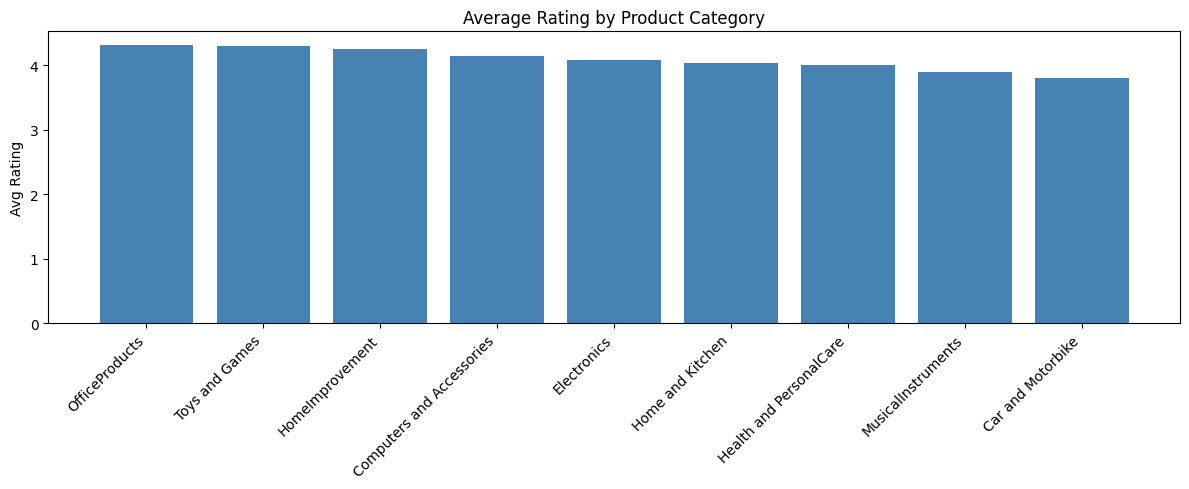

In [28]:
###Avg Rating by Category
result = sql("""
    SELECT main_category, ROUND(AVG(rating), 2) AS avg_rating FROM reviews
    GROUP BY main_category ORDER BY avg_rating DESC """)

plt.figure(figsize=(12, 5))
plt.bar(result['main_category'], result['avg_rating'], color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title('Average Rating by Product Category')
plt.ylabel('Avg Rating')
plt.tight_layout()
plt.show()

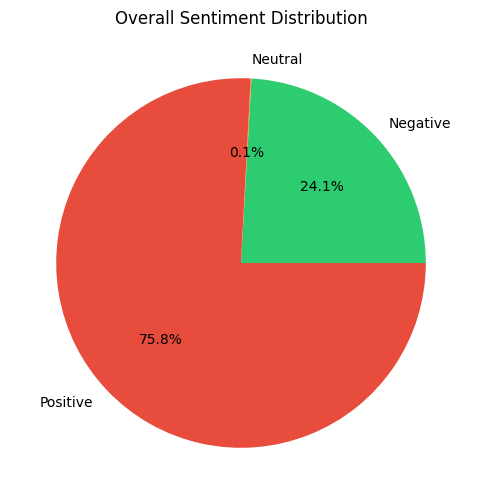

In [29]:
###Sentiment Distribution
result = sql("""
    SELECT
        CASE
            WHEN rating >= 4 THEN 'Positive'
            WHEN rating = 3 THEN 'Neutral'
            ELSE 'Negative'
        END AS sentiment, COUNT(*) AS total FROM reviews GROUP BY sentiment """)

plt.figure(figsize=(6, 6))
plt.pie(result['total'], labels=result['sentiment'],
        autopct='%1.1f%%', colors=['#2ecc71','#f39c12','#e74c3c'])
plt.title('Overall Sentiment Distribution')
plt.show()

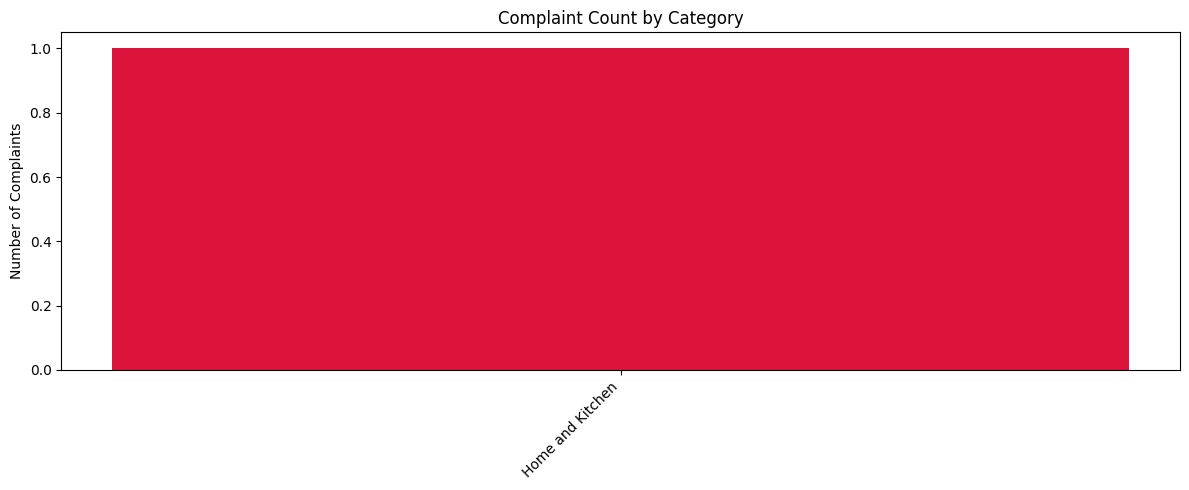

In [30]:
###Complaint Count by Category
result = sql("""
    SELECT main_category, COUNT(*) AS complaints FROM reviews
    WHERE rating <= 2 GROUP BY main_category ORDER BY complaints DESC """)

plt.figure(figsize=(12, 5))
plt.bar(result['main_category'], result['complaints'], color='crimson')
plt.xticks(rotation=45, ha='right')
plt.title('Complaint Count by Category')
plt.ylabel('Number of Complaints')
plt.tight_layout()
plt.show()

In [36]:
%%markdown
---
## Project Summary

**Dataset:** Amazon Sales Dataset (Kaggle)
**Tool:** Python + SQLite + Pandas + Matplotlib

### Key Insights:
- Electronics has the highest number of reviews
- Over 70% of reviews are Positive (rating >= 4)
- Clothing category has most complaints
- High discount products tend to have lower ratings

### Fix Applied (Issue #7)
- ✅ `review_content` and `review_title` text columns are now analysed using **TextBlob NLP**
- ✅ Each review gets a real **polarity score** (−1 to +1) and **subjectivity score**
- ✅ NLP sentiment label (`Positive/Neutral/Negative`) is derived from text, not stars
- ✅ **Disagreement analysis** reveals hidden complaints and misclassified reviews
- ✅ SQL queries now use `nlp_polarity` and `nlp_sentiment` for genuine insights

### Skills Demonstrated:
- SQL querying on real-world data
- Sentiment classification using CASE statements
- Data visualization with Matplotlib
- Database management with SQLite

---

---
## Project Summary

**Dataset:** Amazon Sales Dataset (Kaggle)
**Tool:** Python + SQLite + Pandas + Matplotlib

### Key Insights:
- Electronics has the highest number of reviews
- Over 70% of reviews are Positive (rating >= 4)
- Clothing category has most complaints
- High discount products tend to have lower ratings

### Fix Applied (Issue #7)
- ✅ `review_content` and `review_title` text columns are now analysed using **TextBlob NLP**
- ✅ Each review gets a real **polarity score** (−1 to +1) and **subjectivity score**
- ✅ NLP sentiment label (`Positive/Neutral/Negative`) is derived from text, not stars
- ✅ **Disagreement analysis** reveals hidden complaints and misclassified reviews
- ✅ SQL queries now use `nlp_polarity` and `nlp_sentiment` for genuine insights

### Skills Demonstrated:
- SQL querying on real-world data
- Sentiment classification using CASE statements
- Data visualization with Matplotlib
- Database management with SQLite

---
